In [1]:
import geopandas as gpd
import rasterio
from rasterio.features import rasterize
import matplotlib.pyplot as plt
from rasterio.plot import show
import numpy as np

vector_path = "../data/processed/zuerich_biotopes_superclasses.gpkg"
raster_template_path = "../data/raw/swissimage-dop10_2025_2684-1248_0.1_2056.tif"
output_mask_path = "../data/processed/mask_2684-1248.tif"

gdf = gpd.read_file(vector_path)

with rasterio.open(raster_template_path) as src:
    meta = src.meta.copy()
    transform = src.transform
    width = src.width
    height = src.height
    bbox = src.bounds
    
    rgb_image = src.read()

gdf_clipped = gdf.cx[bbox.left:bbox.right, bbox.bottom:bbox.top]
print(f"Found {len(gdf_clipped)} polygons within this specific tile.")

shapes = ((geom, value) for geom, value in zip(gdf_clipped.geometry, gdf_clipped['label_id']))

mask_array = rasterize(
    shapes=shapes,
    out_shape=(height, width),
    transform=transform,
    fill=255,        
    dtype='uint8'
)

meta.update(count=1, dtype='uint8', nodata=255)

with rasterio.open(output_mask_path, 'w', **meta) as out_raster:
    out_raster.write(mask_array, 1)

print(f"Success! Mask saved to {output_mask_path}")

Found 1266 polygons within this specific tile.


Success! Mask saved to ../data/processed/mask_2684-1248.tif


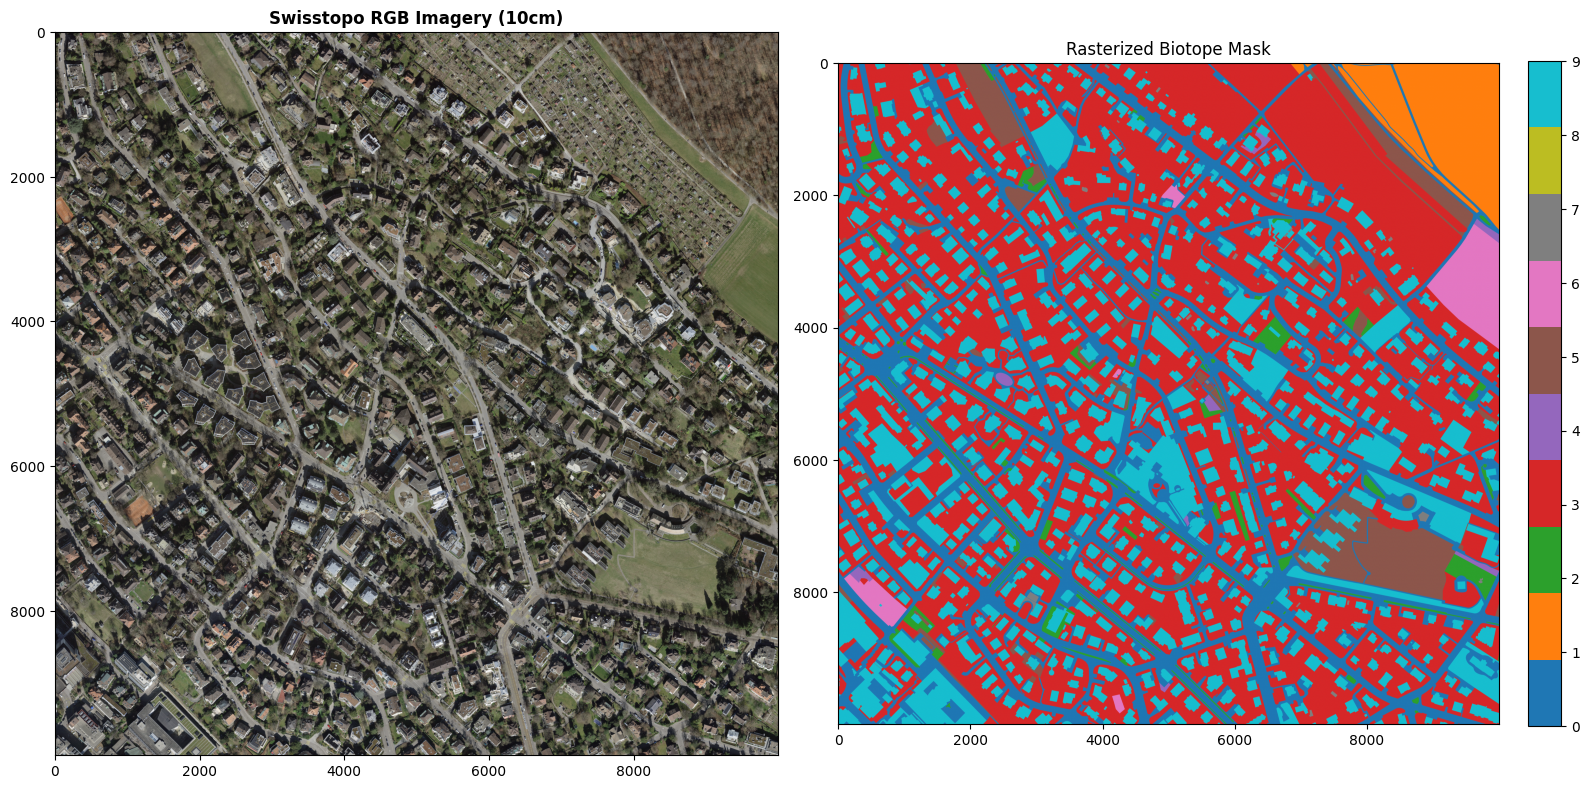

In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

show(rgb_image, ax=ax1, title="Swisstopo RGB Imagery (10cm)")

im = ax2.imshow(mask_array, cmap='tab10', vmin=0, vmax=9)
ax2.set_title("Rasterized Biotope Mask")
plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [3]:
import os

base_dir = "../data/model_ready"

images_dir = os.path.join(base_dir, "images")
masks_dir = os.path.join(base_dir, "masks")

os.makedirs(images_dir, exist_ok=True)
os.makedirs(masks_dir, exist_ok=True)

In [4]:
from rasterio.windows import Window

rgb_path = "../data/raw/swissimage-dop10_2025_2684-1248_0.1_2056.tif"
mask_path = "../data/processed/mask_2684-1248.tif"

out_img_dir = "../data/model_ready/images"
out_mask_dir = "../data/model_ready/masks"

tile_size = 1000

print(f"Starting tiling process. Target tile size: {tile_size}x{tile_size} pixels.")

with rasterio.open(rgb_path) as src_rgb, rasterio.open(mask_path) as src_mask:
    width = src_rgb.width
    height = src_rgb.height
    
    meta_rgb = src_rgb.meta.copy()
    meta_mask = src_mask.meta.copy()
    
    meta_rgb.update(width=tile_size, height=tile_size)
    meta_mask.update(width=tile_size, height=tile_size)
    
    tile_count = 0
    
    for col_off in range(0, width, tile_size):
        for row_off in range(0, height, tile_size):
            
            window = Window(col_off, row_off, tile_size, tile_size)
            
            rgb_window = src_rgb.read(window=window)
            mask_window = src_mask.read(1, window=window)
            
            if (mask_window == 255).all():
                continue
                
            transform_window = src_rgb.window_transform(window)
            meta_rgb.update(transform=transform_window)
            meta_mask.update(transform=transform_window)
            
            tile_name = f"tile_{col_off}_{row_off}.tif"
            img_out_path = os.path.join(out_img_dir, tile_name)
            mask_out_path = os.path.join(out_mask_dir, tile_name)
            
            with rasterio.open(img_out_path, 'w', **meta_rgb) as dest_rgb:
                dest_rgb.write(rgb_window)
                
            with rasterio.open(mask_out_path, 'w', **meta_mask) as dest_mask:
                dest_mask.write(mask_window, 1)
                
            tile_count += 1

print(f"Success! Generated {tile_count} perfectly paired image/mask tiles.")

Starting tiling process. Target tile size: 1000x1000 pixels.


Success! Generated 100 perfectly paired image/mask tiles.


Inspecting random tile: tile_0_9000.tif


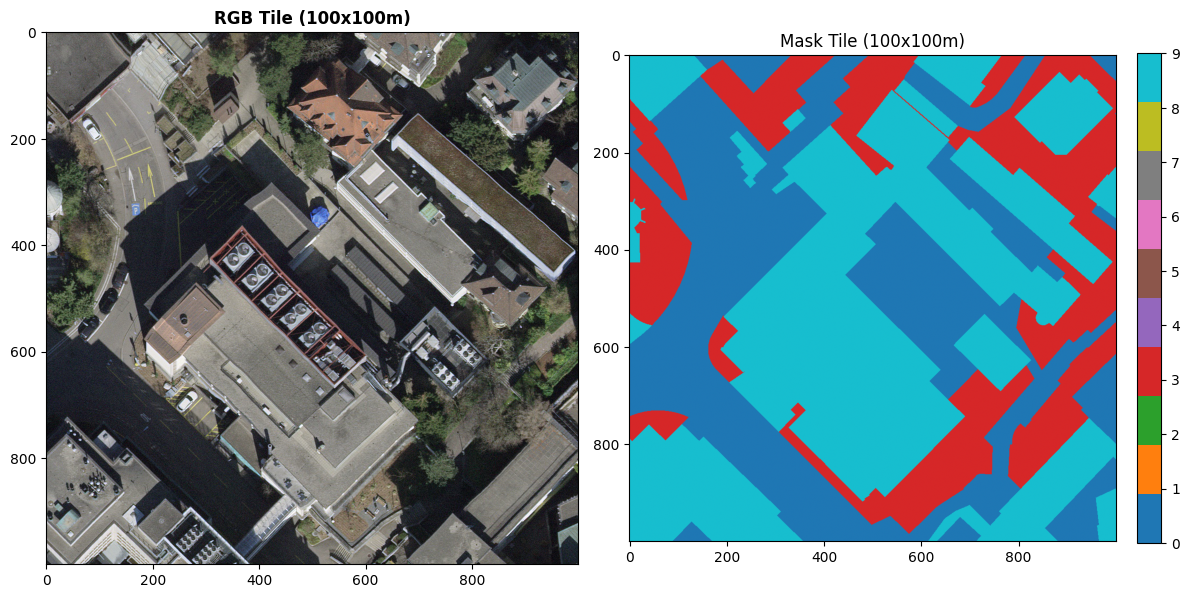

In [5]:
import random

img_dir = "../data/model_ready/images"
mask_dir = "../data/model_ready/masks"

tile_files = os.listdir(img_dir)

random_tile = random.choice(tile_files)
print(f"Inspecting random tile: {random_tile}")

img_path = os.path.join(img_dir, random_tile)
mask_path = os.path.join(mask_dir, random_tile)

with rasterio.open(img_path) as src_img, rasterio.open(mask_path) as src_mask:
    rgb_tile = src_img.read()
    mask_tile = src_mask.read(1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

show(rgb_tile, ax=ax1, title="RGB Tile (100x100m)")

im = ax2.imshow(mask_tile, cmap='tab10', vmin=0, vmax=9)
ax2.set_title("Mask Tile (100x100m)")
plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()